# ATDL — Official Final Evaluation and Visual Report

This notebook evaluates only checkpoints frozen before official CIFAR-10 test access. It creates reproducible visual evidence for the teacher, FP32 student, ternary QAT baseline, vanilla ternary-KD final control, and the exploratory QTRD screen. No training or test-based model selection occurs here.

In [1]:
from pathlib import Path
import json, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('/home/vu-lab03-pc17/ATDL-1').resolve()
PLOTS = ROOT / 'plots/final_official'
PLOTS.mkdir(parents=True, exist_ok=True)
EVALUATOR = ROOT / 'scripts/run_official_final_evaluation.py'
REPORT = ROOT / 'results/final_official_test_evaluation.json'
assert EVALUATOR.is_file()
print('Final-report root:', ROOT)
print('Official test protocol: frozen checkpoints only; no test-driven tuning.')

Final-report root: /home/vu-lab03-pc17/ATDL-1
Official test protocol: frozen checkpoints only; no test-driven tuning.


In [2]:
# Explicit final-evaluation unlock, authorized by the project owner.
# The evaluator refuses overwrites, preserving a one-time immutable test report.
if not REPORT.exists():
    subprocess.run([sys.executable, str(EVALUATOR), '--final-evaluation'], cwd=ROOT, check=True)
else:
    print('Using immutable existing official report:', REPORT)

FP32 ResNet34 teacher | resnet34_cifar10_fp32_best.pth | val=95.54% | test=95.19%
FP32 ResNet18 baseline | resnet18_fp32_seed42.pth | val=95.34% | test=95.09%
FP32 ResNet18 baseline | resnet18_fp32_seed43.pth | val=95.46% | test=94.94%
FP32 ResNet18 baseline | resnet18_fp32_seed44.pth | val=95.18% | test=95.01%
Ternary ResNet18 (no KD) | resnet18_ternary_seed42.pth | val=95.12% | test=94.67%
Ternary ResNet18 (no KD) | resnet18_ternary_seed43.pth | val=95.22% | test=94.74%
Ternary ResNet18 (no KD) | resnet18_ternary_seed44.pth | val=95.28% | test=94.67%
Vanilla ternary KD (final control) | resnet18_ternary_kd_seed42.pth | val=95.14% | test=94.81%
Vanilla ternary KD (final control) | resnet18_ternary_kd_seed43.pth | val=94.96% | test=94.97%
Vanilla ternary KD (final control) | resnet18_ternary_kd_seed44.pth | val=95.26% | test=94.83%
QTRD exploratory screen | resnet18_ternary_kd_seed42.pth | val=95.06% | test=94.83%
Saved immutable official report: /home/vu-lab03-pc17/ATDL-1/results/fina

In [3]:
official = json.loads(REPORT.read_text())
assert official['purpose'] == 'official_final_reporting_only'
assert 'no test-based model selection' in official['selection_policy']
for name, group in official['groups'].items():
    print(f"{name:36s}  test={100*group['test_accuracy_mean']:.2f}% ± {100*group['test_accuracy_std']:.2f}%  n={group['n_checkpoints']}")
print('\nFinal selection:', official['final_control'])

FP32 ResNet18 baseline                test=95.01% ± 0.08%  n=3
FP32 ResNet34 teacher                 test=95.19% ± 0.00%  n=1
QTRD exploratory screen               test=94.83% ± 0.00%  n=1
Ternary ResNet18 (no KD)              test=94.69% ± 0.04%  n=3
Vanilla ternary KD (final control)    test=94.87% ± 0.09%  n=3

Final selection: Vanilla ternary KD (Task 4), selected from its three-seed validation aggregate before test access.


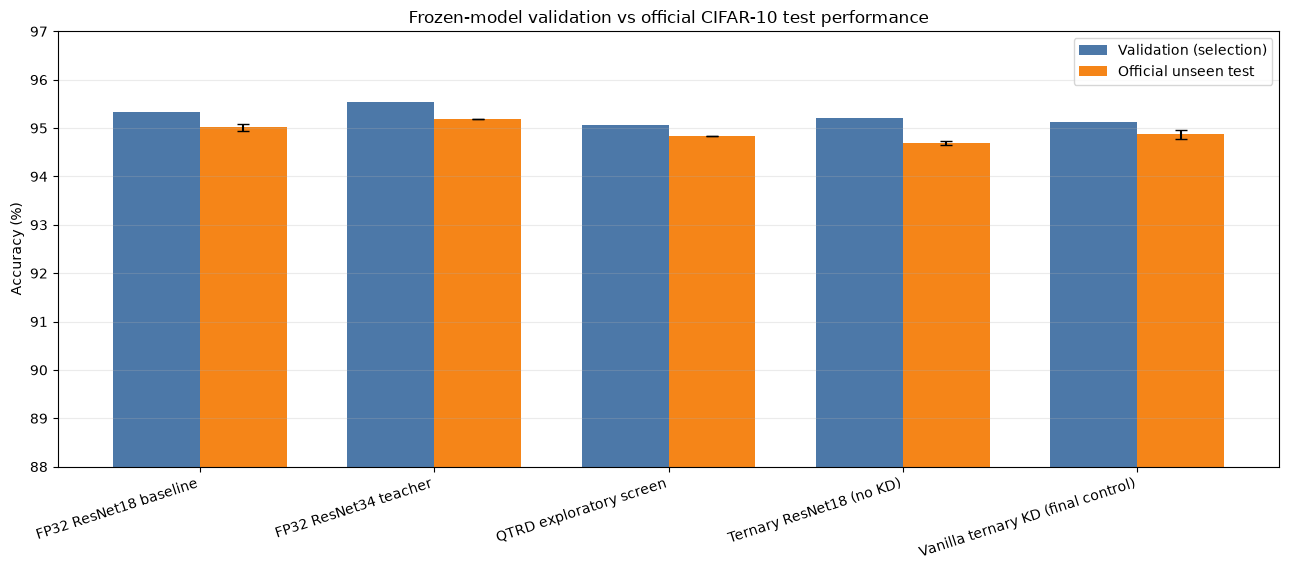

In [4]:
# Validation and official-test comparison (means and independent-checkpoint uncertainty).
val = {
    'FP32 ResNet34 teacher': 0.9554,
    'FP32 ResNet18 baseline': json.loads((ROOT/'results/task2_final_summary.json').read_text())['validation_mean'],
    'Ternary ResNet18 (no KD)': json.loads((ROOT/'results/task3_b2_default_summary.json').read_text())['validation_mean'],
    'Vanilla ternary KD (final control)': json.loads((ROOT/'results/task4/task4_b3_final_t2_lam09_aggregate_summary.json').read_text())['validation_mean'],
    'QTRD exploratory screen': json.loads((ROOT/'results/task4/task11_qtrd_finaltwo_screen_t2_lam09_aux1_r1_summary.json').read_text())['validation_mean'],
}
names = list(official['groups'])
x = np.arange(len(names)); width = 0.37
fig, ax = plt.subplots(figsize=(13, 5.8))
ax.bar(x-width/2, [100*val[n] for n in names], width, label='Validation (selection)', color='#4C78A8')
ax.bar(x+width/2, [100*official['groups'][n]['test_accuracy_mean'] for n in names], width, yerr=[100*official['groups'][n]['test_accuracy_std'] for n in names], capsize=4, label='Official unseen test', color='#F58518')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(88, 97); ax.set_xticks(x, names, rotation=18, ha='right'); ax.set_title('Frozen-model validation vs official CIFAR-10 test performance'); ax.legend(); ax.grid(axis='y', alpha=.25)
fig.tight_layout(); fig.savefig(PLOTS/'validation_vs_official_test.png', dpi=190); plt.show()

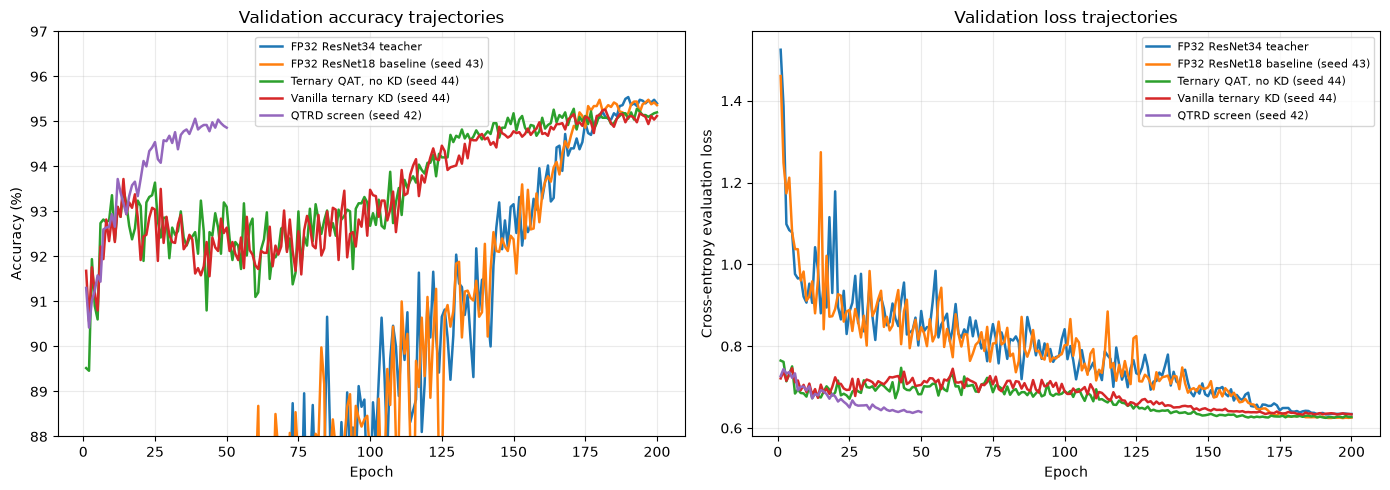

In [5]:
# Real training trajectories: teacher vs FP32 student vs pre-KD and post-KD ternary students.
def history(path):
    raw = json.loads(Path(path).read_text()); return raw.get('history', raw)
sources = {
    'FP32 ResNet34 teacher': ROOT/'training_history.json',
    'FP32 ResNet18 baseline (seed 43)': ROOT/'experiments/histories/task2_b1_fp32_resnet18/resnet18_fp32_seed43.json',
    'Ternary QAT, no KD (seed 44)': ROOT/'experiments/histories/task3_b2_default/resnet18_ternary_seed44.json',
    'Vanilla ternary KD (seed 44)': ROOT/'experiments/task4/histories/task4_b3_final_t2_lam09_remaining_rerun1/seed44.json',
    'QTRD screen (seed 42)': ROOT/'experiments/task4/histories/task11_qtrd_finaltwo_screen_t2_lam09_aux1_r1/seed42.json',
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, path in sources.items():
    h = history(path); epoch = np.arange(1, len(h['val_acc'])+1)
    axes[0].plot(epoch, 100*np.asarray(h['val_acc']), label=label, linewidth=1.8)
    axes[1].plot(epoch, h['val_loss'], label=label, linewidth=1.8)
axes[0].set(title='Validation accuracy trajectories', xlabel='Epoch', ylabel='Accuracy (%)', ylim=(88, 97))
axes[1].set(title='Validation loss trajectories', xlabel='Epoch', ylabel='Cross-entropy evaluation loss')
for ax in axes: ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(PLOTS/'teacher_student_pre_post_kd_curves.png', dpi=190); plt.show()

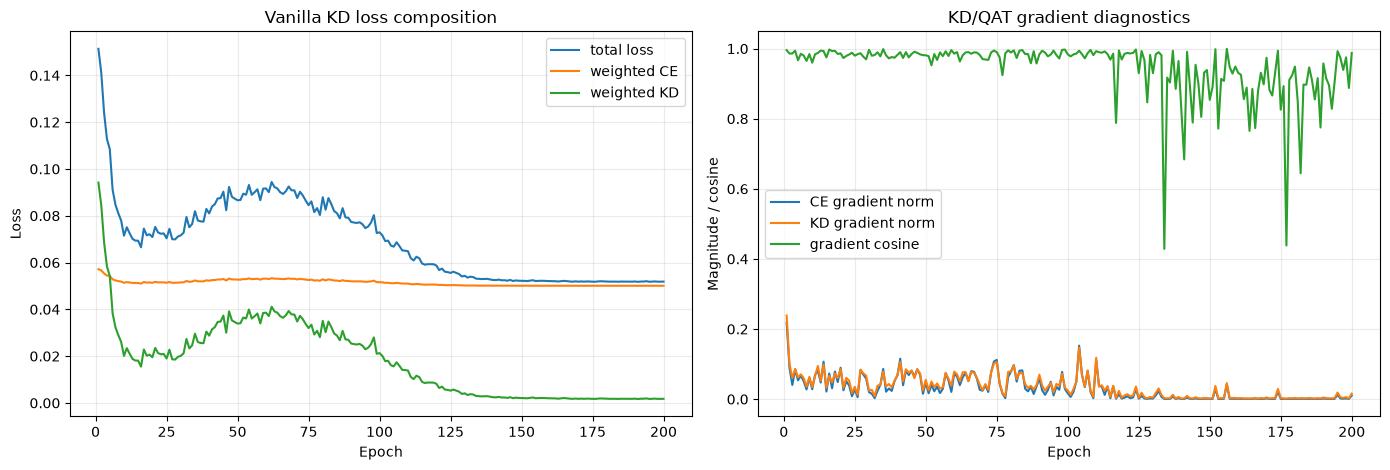

In [6]:
# KD/QAT stability diagnostics for the final three-seed vanilla-KD run.
h = history(ROOT/'experiments/task4/histories/task4_b3_final_t2_lam09_remaining_rerun1/seed44.json')
epoch = np.arange(1, len(h['total_loss'])+1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(epoch, h['total_loss'], label='total loss'); axes[0].plot(epoch, h['weighted_ce'], label='weighted CE'); axes[0].plot(epoch, h['weighted_kd'], label='weighted KD')
axes[0].set(title='Vanilla KD loss composition', xlabel='Epoch', ylabel='Loss')
axes[1].plot(epoch, h['ce_grad_norm'], label='CE gradient norm'); axes[1].plot(epoch, h['kd_grad_norm'], label='KD gradient norm'); axes[1].plot(epoch, h['grad_cosine'], label='gradient cosine')
axes[1].set(title='KD/QAT gradient diagnostics', xlabel='Epoch', ylabel='Magnitude / cosine')
for ax in axes: ax.grid(alpha=.25); ax.legend()
fig.tight_layout(); fig.savefig(PLOTS/'vanilla_kd_stability_diagnostics.png', dpi=190); plt.show()

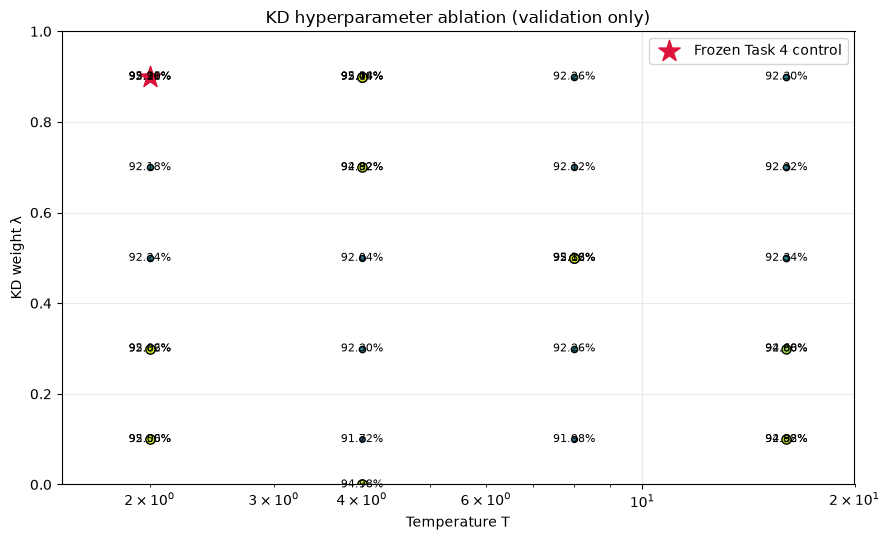

In [7]:
# Ablation visual: every preserved T/lambda screen with a recorded validation mean.
ablation = []
for path in sorted((ROOT/'results/task4').glob('task4_tlambda_*_summary.json')):
    d = json.loads(path.read_text())
    if d.get('validation_mean') is not None:
        ablation.append((d.get('temperature'), d.get('kd_lambda'), d['validation_mean'], path.stem))
ablation.sort()
fig, ax = plt.subplots(figsize=(9, 5.5))
for t, lam, score, label in ablation:
    ax.scatter(t, lam, s=900*(score-.90), c=[score], cmap='viridis', vmin=.90, vmax=.955, edgecolor='black')
    ax.annotate(f'{100*score:.2f}%', (t, lam), ha='center', va='center', fontsize=8)
ax.scatter(2.0, .9, marker='*', s=260, color='crimson', label='Frozen Task 4 control')
ax.set(title='KD hyperparameter ablation (validation only)', xlabel='Temperature T', ylabel='KD weight λ', xscale='log', xlim=(1.5, 20), ylim=(0, 1)); ax.grid(alpha=.25); ax.legend()
fig.tight_layout(); fig.savefig(PLOTS/'kd_temperature_lambda_ablation.png', dpi=190); plt.show()

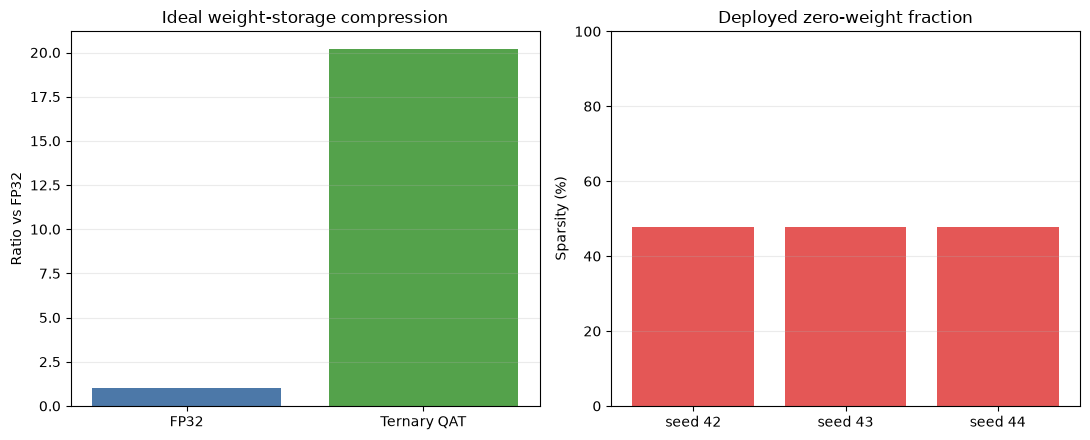

All final-control Conv/FC layers are ternary. Mean sparsity=47.70%; ideal ratio=20.19× before scale/packing overhead.


In [8]:
# Compression, sparsity, and ternary verification for frozen final-control checkpoints.
control = official['groups']['Vanilla ternary KD (final control)']['per_checkpoint']
assert all(row['ternary_verification']['all_ternary'] for row in control)
assert all(row['ternary_verification']['all_weight_layers_ternary'] for row in control)
sparsity = [row['ternary_verification']['sparsity'] for row in control]
compression = [row['ternary_verification']['compression_vs_fp32'] for row in control]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(['FP32', 'Ternary QAT'], [1, np.mean(compression)], color=['#4C78A8','#54A24B']); axes[0].set(title='Ideal weight-storage compression', ylabel='Ratio vs FP32'); axes[0].grid(axis='y', alpha=.25)
axes[1].bar(['seed 42','seed 43','seed 44'], 100*np.asarray(sparsity), color='#E45756'); axes[1].set(title='Deployed zero-weight fraction', ylabel='Sparsity (%)', ylim=(0,100)); axes[1].grid(axis='y', alpha=.25)
fig.tight_layout(); fig.savefig(PLOTS/'compression_and_sparsity.png', dpi=190); plt.show()
print(f'All final-control Conv/FC layers are ternary. Mean sparsity={100*np.mean(sparsity):.2f}%; ideal ratio={np.mean(compression):.2f}× before scale/packing overhead.')

/tmp/ipykernel_111712/2403247991.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(PLOTS/'official_test_confusion_teacher_vs_kd.png', dpi=190); plt.show()


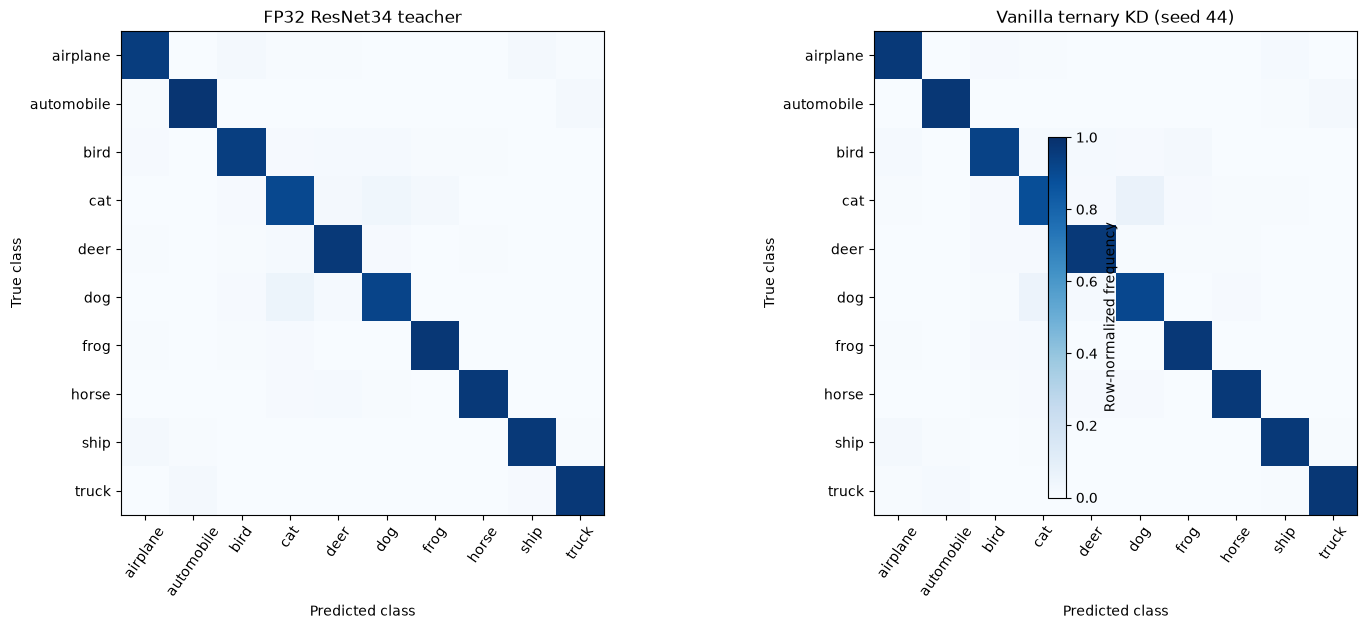

In [9]:
# Official-test classwise error patterns: teacher vs selected vanilla ternary-KD checkpoint (seed 44).
teacher_cm = np.asarray(official['groups']['FP32 ResNet34 teacher']['per_checkpoint'][0]['test_confusion_matrix'])
kd_cm = np.asarray(official['groups']['Vanilla ternary KD (final control)']['per_checkpoint'][2]['test_confusion_matrix'])
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, cm, title in zip(axes, [teacher_cm, kd_cm], ['FP32 ResNet34 teacher', 'Vanilla ternary KD (seed 44)']):
    image = ax.imshow(cm / cm.sum(axis=1, keepdims=True), vmin=0, vmax=1, cmap='Blues')
    ax.set(title=title, xlabel='Predicted class', ylabel='True class', xticks=range(10), xticklabels=classes, yticks=range(10), yticklabels=classes)
    ax.tick_params(axis='x', rotation=55)
fig.colorbar(image, ax=axes, shrink=.78, label='Row-normalized frequency')
fig.tight_layout(); fig.savefig(PLOTS/'official_test_confusion_teacher_vs_kd.png', dpi=190); plt.show()

In [10]:
# Immutable completion manifest for the final submission bundle.
manifest = {
    'official_report': str(REPORT.relative_to(ROOT)),
    'plots': [str(p.relative_to(ROOT)) for p in sorted(PLOTS.glob('*.png'))],
    'final_control_checkpoint': 'experiments/task4/checkpoints/task4_b3_final_t2_lam09_remaining_rerun1/resnet18_ternary_kd_seed44.pth',
    'test_protocol': official['selection_policy'],
}
out = ROOT/'report/final_official_evaluation_manifest.json'
assert not out.exists(), f'Refusing to overwrite {out}'
out.write_text(json.dumps(manifest, indent=2)+'\n')
print(json.dumps(manifest, indent=2))

{
  "official_report": "results/final_official_test_evaluation.json",
  "plots": [
    "plots/final_official/compression_and_sparsity.png",
    "plots/final_official/kd_temperature_lambda_ablation.png",
    "plots/final_official/official_test_confusion_teacher_vs_kd.png",
    "plots/final_official/teacher_student_pre_post_kd_curves.png",
    "plots/final_official/validation_vs_official_test.png",
    "plots/final_official/vanilla_kd_stability_diagnostics.png"
  ],
  "final_control_checkpoint": "experiments/task4/checkpoints/task4_b3_final_t2_lam09_remaining_rerun1/resnet18_ternary_kd_seed44.pth",
  "test_protocol": "All models/checkpoints were frozen before first test access; no test-based model selection or tuning occurred."
}
